In [16]:
# Step 1 - Import Libraries
# tensorflow is our main deep learning framework
import tensorflow as tf

# matplotlib lets us visualize images and training results
import matplotlib.pyplot as plt

# numpy helps us work with numbers and arrays
import numpy as np

# partial lets us create a "default" version of a function with preset settings
# we'll use this later to avoid repeating ourselves when building the CNN
from functools import partial

In [17]:
# Step 2 - Load the Data

# load training images from the train folder
# image_size resizes all images to 64x64 pixels so they're all the same size
# batch_size=32 means we feed 32 images at a time to the model during training
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/train",
    image_size=(64, 64),
    batch_size=32
)

# load test images — same settings, different folder
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/test",
    image_size=(64, 64),
    batch_size=32
)

Found 2301 files belonging to 10 classes.
Found 1025 files belonging to 10 classes.


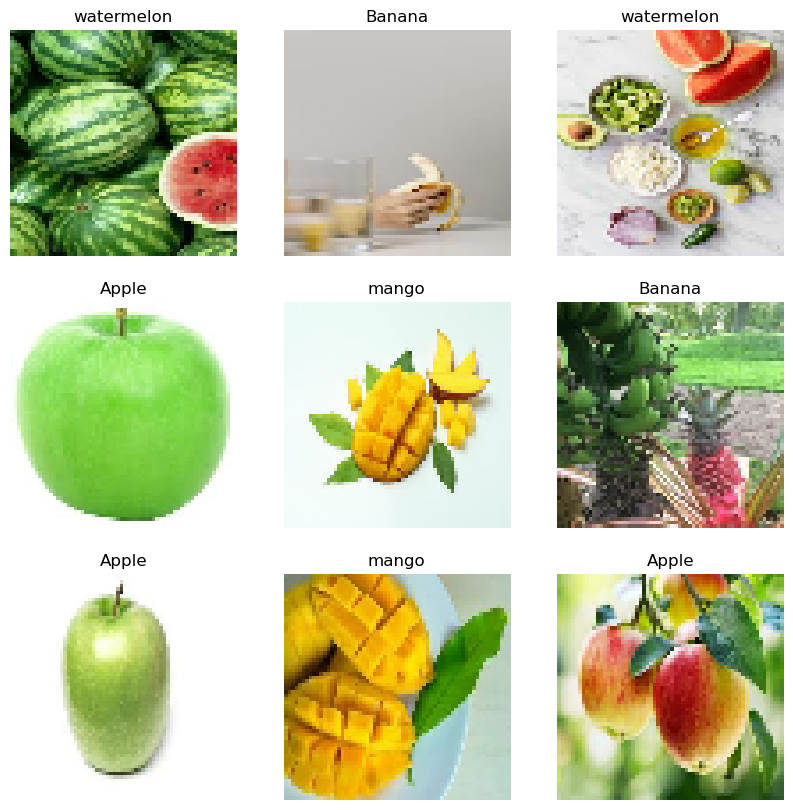

In [18]:
# Step 2.5 - Visualize Some Training Images
# this helps us make sure the data loaded correctly before we do anything else

# create a 10x10 figure to display our images
plt.figure(figsize=(10, 10))

# take(1) grabs just the first batch of 32 images
for images, labels in train_ds.take(1):
    
    # show 9 images in a 3x3 grid
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # imshow expects values 0-255, so we convert back with astype("uint8")
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # class_names gives us the fruit name from the label number e.g. 0 → "Apple"
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [19]:
# Step 3 - Normalize the Data

# pixel values in images range from 0 to 255 (e.g. 128, 200, 45...)
# neural networks work much better when numbers are small (between 0 and 1)
# so we divide every pixel by 255 to shrink the range → 0.0 to 1.0
normalization_layer = tf.keras.layers.Rescaling(1./255)

# apply the normalization to every image in the training set
# lambda x, y means: for each (image, label) pair, rescale the image, keep the label as is
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# same for the test set
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [20]:
# Step 4 - Data Augmentation
# remember our overfitting problem? training 64% but validation only 46%?
# augmentation helps fix this by creating new variations of our training images
# so the model sees more diversity and can't just memorize the training set

data_augmentation = tf.keras.Sequential([
    # randomly flip the image horizontally (mirror effect)
    # an apple is still an apple whether flipped or not!
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    
    # randomly rotate the image slightly (max 5% of 360° = ~18 degrees)
    # a mango is still a mango even if slightly tilted
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    
    # randomly adjust the contrast slightly
    # helps the model handle different lighting conditions
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

In [21]:
# Step 5 - Build the CNN Model

DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")

model = tf.keras.Sequential([
    # data augmentation is the first layer!
    # it only applies during training, automatically turns off during validation
    data_augmentation,
    
    DefaultConv2D(filters=32, kernel_size=7, input_shape=[64, 64, 3]),
    tf.keras.layers.MaxPooling2D(),

    DefaultConv2D(filters=64),
    DefaultConv2D(filters=64),
    tf.keras.layers.MaxPooling2D(),

    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [22]:
# Step 6 - Compile the Model
# this is where we tell the model HOW to learn

# loss function: measures how wrong the model is after each batch
# sparse_categorical_crossentropy is used when we have multiple classes (10 fruits)
# and our labels are integers (0, 1, 2... not one-hot encoded)

# optimizer: the strategy the model uses to fix its mistakes
# sgd = Stochastic Gradient Descent, a classic optimizer
# it nudges the weights in the direction that reduces the loss

# metrics: what we want to monitor during training
# accuracy = how many images the model classified correctly
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [23]:
# Step 7 - Train the Model
# epochs=20 means the model will go through all 2301 training images 20 times
# each epoch it gets a little better at recognizing fruits
# validation_data=test_ds lets us see how it performs on unseen images after each epoch
history = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.1777 - loss: 2.2202 - val_accuracy: 0.2117 - val_loss: 2.1761
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.2664 - loss: 1.9037 - val_accuracy: 0.2380 - val_loss: 1.9065
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3086 - loss: 1.7994 - val_accuracy: 0.3054 - val_loss: 1.8138
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.3698 - loss: 1.6811 - val_accuracy: 0.3200 - val_loss: 1.8758
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.3842 - loss: 1.6312 - val_accuracy: 0.3083 - val_loss: 1.9766
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4055 - loss: 1.5854 - val_accuracy: 0.3629 - val_loss: 1.7102
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.4229 - loss: 1.5399 - val_accuracy: 0.3444 - val_loss: 1.9194
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.4272 - loss: 1.5368 - val_accuracy: 0.3766 - v